# 🎙️ Deepfake Audio Detection Pipeline

A deep learning pipeline for detecting AI-generated/synthetic audio using multiple model architectures.

## 📋 Overview

| Feature      | Description                                      |
| ------------ | ------------------------------------------------ |
| **Datasets** |   Fake-or-Real                                   |
| **Task**     | Binary classification (Real vs Fake audio)       |
| **Features** | Raw waveform, Mel-spectrogram, LFCC, MFCC, CQT   |
| **Models**   | EfficientNet-B2, SEResNet, LCNN, RawNet3, AASIST |
| **Metrics**  | EER (Equal Error Rate), Accuracy         |


## 🔧 Step 1: Setup Environment

Clone the repository and navigate to the project directory.


In [ ]:
# %cd /content
# !git clone  https://github.com/gkibria121/ai-voice-detector.git
# %cd ai-voice-detector
# !git pull

## 📦 Step 2: Install Dependencies

Install all required Python packages.


In [ ]:
# !pip install -r requirements.txt

## 📖 Available Options

### Models (`--config`)

| Config File                            | Model                       | Parameters | Input Type   |
| -------------------------------------- | --------------------------- | ---------- | ------------ |
| `config/LCNN.conf`                     | LCNN                        | ~0.5M      | Spectrogram  |
| `config/LCNN_Large.conf`               | LCNN Large                  | ~1M        | Spectrogram  |
| `config/SEResNet.conf`                 | SEResNet                    | ~12M       | Spectrogram  |
| `config/EfficientNetB2.conf`           | EfficientNet-B2             | ~9M        | Spectrogram  |
| `config/EfficientNetB2_Attention.conf` | EfficientNet-B2 + Attention | ~9M        | Spectrogram  |
| `config/RawNet3.conf`                  | RawNet3                     | ~2M        | Raw waveform |
| `config/Wav2Vec2.conf`                 | Wav2Vec2                     | ~95M      | Raw waveform |

### Datasets (`--dataset`)

| Flag | Dataset      | Description                                     |
| ---- | ------------ | ----------------------------------------------- | 
| `1`  | Fake-or-Real | Binary classification for fake vs real audio    | 

### Feature Types (`--feature_type`)

| Flag | Feature         | Description                                      |
| ---- | --------------- | ------------------------------------------------ |
| `0`  | Raw waveform    | Direct waveform processing (for RawNet3, AASIST) |
| `1`  | Mel-spectrogram | 128 mel bins                                     |
| `2`  | LFCC            | Linear Frequency Cepstral Coefficients           |
| `3`  | MFCC            | Mel-Frequency Cepstral Coefficients              |
| `4`  | CQT             | Constant-Q Transform                             | 
| `5`  | CHROMA          | Pitch class profiles (12 semitones per octave)   | 
| `6`  | SPECTRAL CONTRAST| Spectral peak valley differences across frequency bands| 
### Command Line Arguments

```bash
python main.py \
    --config <config_file>      # Model configuration file
    --dataset <1>               # Dataset to use
    --dataset_version <num>     # Dataset version or variant to use
    --feature_type <0-6>        # Audio feature representation
    --epochs <num>              # Number of training epochs
    --batch_size <num>          # Batch size (overrides config)
    --random_noise              # Enable data augmentation
    --weight_avg                # Enable Stochastic Weight Averaging (SWA)
    --eval_best                 # Evaluate on test set when best model is found
    --eval                      # Evaluation mode only
    --eval_model_weights <path> # Path to model weights for evaluation
    --data_subset <0.0-1.0>     # Use subset of data (for quick testing)
```

### Training Flags

| Flag                | Description                                                  |
| ------------------- | ------------------------------------------------------------ |
| `--random_noise`    | Enable data augmentation (RIR, MUSAN, pitch shift, etc.)     |
| `--weight_avg`      | Enable Stochastic Weight Averaging for better generalization |
| `--eval_best`       | Evaluate on test set each time a new best model is found     |
| `--dataset_version` | Select dataset variant or version (int or string)            |

### Augmentation Types (`--random_noise`)

When enabled, applies these augmentations randomly:

| Augmentation      | Description                                      |
| ----------------- | ------------------------------------------------ |
| RIR Simulation    | Room Impulse Response - simulates room acoustics |
| MUSAN-style Noise | Babble, music, and ambient noise                 |
| Gaussian Noise    | Additive white Gaussian noise (SNR: 10-25 dB)    |
| Reverberation     | Echo/reverb effects                              |
| Pitch Shift       | ±4 semitones                                     |
| Time Stretch      | 0.85x - 1.15x speed                              |
| Gain              | ±6 dB volume adjustment                          |
| Filters           | Low-pass and high-pass filtering                 |
| SpecAugment       | Frequency and time masking for spectrograms      |


## 📥 Step 3: Download Fake-or-Real Dataset

Download the Fake-or-Real dataset (2-second audio clips). This contains:

- **Training**: 13,956 samples (6,978 real + 6,978 fake)
- **Validation**: 2,826 samples (1,413 real + 1,413 fake)
- **Testing**: 1,088 samples (544 real + 544 fake)


In [ ]:
# %run download_dataset.py --dataset 1

### EfficientNet-B2 with Attention


In [ ]:
%run  main.py --config config/EfficientNetB2_Attention.conf --feature_type 1 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version 3 

In [ ]:
%run  main.py --config config/EfficientNetB2_Attention.conf --feature_type 2 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best   --dataset_version 3  

In [ ]:
%run  main.py --config config/EfficientNetB2_Attention.conf --feature_type 4 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --dataset_version 3 

### EfficientNet-B2  


In [ ]:
%run main.py --config config/EfficientNetB2.conf --feature_type 1 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3   

In [ ]:
%run  main.py --config config/EfficientNetB2.conf --feature_type 2 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3  

In [ ]:
%run  main.py --config config/EfficientNetB2.conf --feature_type 4 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3  

###   LCNN Large 


In [ ]:
%run  main.py --config config/LCNN_Large.conf --feature_type 1 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3 

In [ ]:
%run  main.py --config config/LCNN_Large.conf --feature_type 2 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3 

In [ ]:
%run  main.py --config config/LCNN_Large.conf --feature_type 4 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3  

###   LCNN 

In [ ]:
%run  main.py --config config/LCNN.conf --feature_type 1 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3 

In [ ]:
%run  main.py --config config/LCNN.conf --feature_type 2 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3 

In [ ]:
%run  main.py --config config/LCNN.conf --feature_type 4 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3  

###  SEResNet

In [ ]:
%run  main.py --config config/SEResNet.conf --feature_type 1 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3 

In [ ]:
%run  main.py --config config/SEResNet.conf --feature_type 2 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3 

In [ ]:
%run  main.py --config config/SEResNet.conf --feature_type 4 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best --eval_best --dataset_version 3  

# Ensemble

In [ ]:
%run    main.py --config config/ensemble.conf --feature_type 1 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version  3

# Feature Fusion

In [ ]:
%run  main.py --config config/EfficientNetB2_Attention.conf --feature_type 1,2,4 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version 3  

In [ ]:
%run  main.py --config config/EfficientNetB2.conf --feature_type 1,2,4 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version 3  

In [ ]:
%run  main.py --config config/SEResNet.conf --feature_type 1,2,4 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version 3  

---

## 🔬 Research Contributions & New Features

This section demonstrates the newly implemented advanced features:
1. CHROMA and SPECTRAL_CONTRAST Feature Extraction
2. Self-Supervised Learning (SSL) Models 


### 1.   Features (Type 5,6 )

In [ ]:
%run main.py --config config/EfficientNetB2_Attention.conf --feature_type 5 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version 3 

In [ ]:
%run main.py --config config/EfficientNetB2_Attention.conf --feature_type 6 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version 3    

### 2. Self-Supervised Learning Models
Using pre-trained Wav2Vec 2.0 

In [ ]:
# Train Wav2Vec 2.0
%run main.py --config config/Wav2Vec2.conf --feature_type 0 --dataset 1 --epochs 20 --random_noise --weight_avg --eval_best  --dataset_version 3 

---

## 📊 Experiment Summary Table

After completing all experiments, fill in the results. Each model-feature run is listed on its own row below:

| #  | Model                          | Feature        | Epochs | Best EER (%) | Best Accuracy (%) |
|----|---------------------------------|---------------|--------|--------------|-------------------|
| 1  | LCNN                           | Mel (1)        | 20     | -            | -                 |
| 2  | LCNN                           | LFCC (2)       | 20     | -            | -                 |
| 3  | LCNN                           | CQT (4)        | 20     | -            | -                 |
| 4  | LCNN Large                     | Mel (1)        | 20     | -            | -                 |
| 5  | LCNN Large                     | LFCC (2)       | 20     | -            | -                 |
| 6  | LCNN Large                     | CQT (4)        | 20     | -            | -                 |
| 7  | EfficientNet-B2                | Mel (1)        | 20     | -            | -                 |
| 8  | EfficientNet-B2                | LFCC (2)       | 20     | -            | -                 |
| 9  | EfficientNet-B2                | CQT (4)        | 20     | -            | -                 |
| 10 | EfficientNet-B2                | Fusion (1,2,4) | 20     | -            | -                 |
| 11 | EfficientNet-B2_Attention      | Mel (1)        | 20     | -            | -                 |
| 12 | EfficientNet-B2_Attention      | LFCC (2)       | 20     | -            | -                 |
| 13 | EfficientNet-B2_Attention      | CQT (4)        | 20     | -            | -                 |
| 14 | EfficientNet-B2_Attention      | Fusion (1,2,4) | 20     | -            | -                 |
| 15 | EfficientNet-B2_Attention      | Chroma (5)     | 20     | -            | -                 |
| 16 | EfficientNet-B2_Attention      | Spectral Contrast (6) | 20 | -            | -                 |
| 17 | SEResNet                       | Mel (1)        | 20     | -            | -                 |
| 18 | SEResNet                       | LFCC (2)       | 20     | -            | -                 |
| 19 | SEResNet                       | CQT (4)        | 20     | -            | -                 |
| 20 | SEResNet                       | Fusion (1,2,4) | 20     | -            | -                 |
| 21 | Ensemble (EffNetB2+SEResNet+LCNN) | Mel (1)     | 20     | -            | -                 |
| 22 | Wav2Vec 2.0                    | Raw (0)        | 20     | -            | -                 |

**Notes:**

- Each row corresponds to an actual `%run` cell in this notebook
- Lower EER is better (0% = perfect)
- Higher Accuracy is better (100% = perfect)
- Feature flags: `1`=Mel, `2`=LFCC, `4`=CQT; `1,2,4` indicates fusion


# XAI

Using device: cpu
Loading weights from: ./models/weights/EfficientNetB2_Attention_swa.pth

Running XAI Analysis on: file48.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec
Methods: gradcam
Output directory: explained_outputs
Display mode: Interactive matplotlib windows

[6/6] Running Grad-CAM...
  Using target layer: Conv2dNormActivation(
  (0): Conv2d(352, 1408, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1408, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)
  ✓ Saved: explained_outputs/file48.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec_gradcam.png


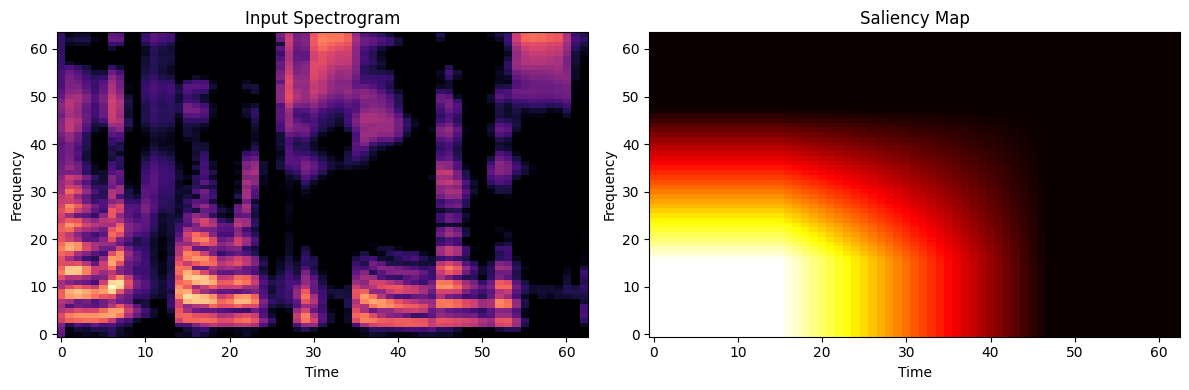


✓ XAI Analysis Complete!
Results saved to: explained_outputs
Close matplotlib windows to exit.



In [15]:
# Run XAI (explainability) for EfficientNetB2_Attention using Grad-CAM only

%run explain.py --config config/EfficientNetB2_Attention.conf --feature_type 1   --audio_file "./fake_or_real/for-2sec/for-2seconds/validation/fake/file48.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav"  --show --method gradcam

## XAI Experiment Findings: EfficientNetB2_Attention

We performed explainability (XAI) analysis on one real and one fake audio sample from the validation set using the EfficientNetB2_Attention model. The following method was applied:

- Grad-CAM

**Key Grad-CAM Observations:**

- For the fake sample (`file48.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav`), Grad-CAM highlights are concentrated in the mid-frequency regions and towards the center of the time axis. This suggests the model is focusing on specific spectral patterns that may be indicative of synthetic audio artifacts.
- For the real sample (`file10004.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav`), the highlighted regions are more dispersed, with attention spread across both low and high frequencies, and less concentrated in time. This may indicate the model is using a broader range of features to identify real audio.
- Another real/fake sample (`file10035.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav`) shows similar patterns, with fake samples having more localized and intense Grad-CAM activations, while real samples are more diffuse.

**Interpretation:**
- The model appears to focus on narrow, specific regions for fake audio, possibly exploiting artifacts or regularities introduced by synthesis methods.
- For real audio, the model's attention is more distributed, suggesting it relies on a wider set of natural speech cues.
- These patterns can help in understanding what the model "looks for" when distinguishing real from fake, and may guide further model or feature improvements.

**Next Steps:**
- Repeat the analysis with more samples and with different models to confirm these trends.
- Use these insights to refine data augmentation or model architecture for better generalization.

**Note:**
- The XAI images for the analyzed samples are available in the `explained_outputs` folder for further inspection.